<a href="https://colab.research.google.com/github/oluchiokoro-debug/colab-git-assignment2-OO/blob/main/Boston_Housing_Regression_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Lesson 7 Assignment
# Boston Housing Price Prediction
# Random Forest Regression
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Data Collection and Loading
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["PRICE"] = housing.target

In [3]:
# Quick Check of Data
print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

First 5 Rows
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Shape
(20640, 9)

Column Names
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'PRICE'],
      dtype='object')

Data Types
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
PRICE         float64
dtyp

In [4]:
# Check Features and Target
X = df.drop("PRICE", axis=1)
y = df["PRICE"]

print("\nFeatures:")
print(X.columns)

print("\nTarget Variable:")
print("PRICE")



Features:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Target Variable:
PRICE


In [5]:
# Check Missing Values
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


In [6]:
# Summary Statistics
print("\nSummary Statistics")
print(df.describe())


Summary Statistics
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         PRICE  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0

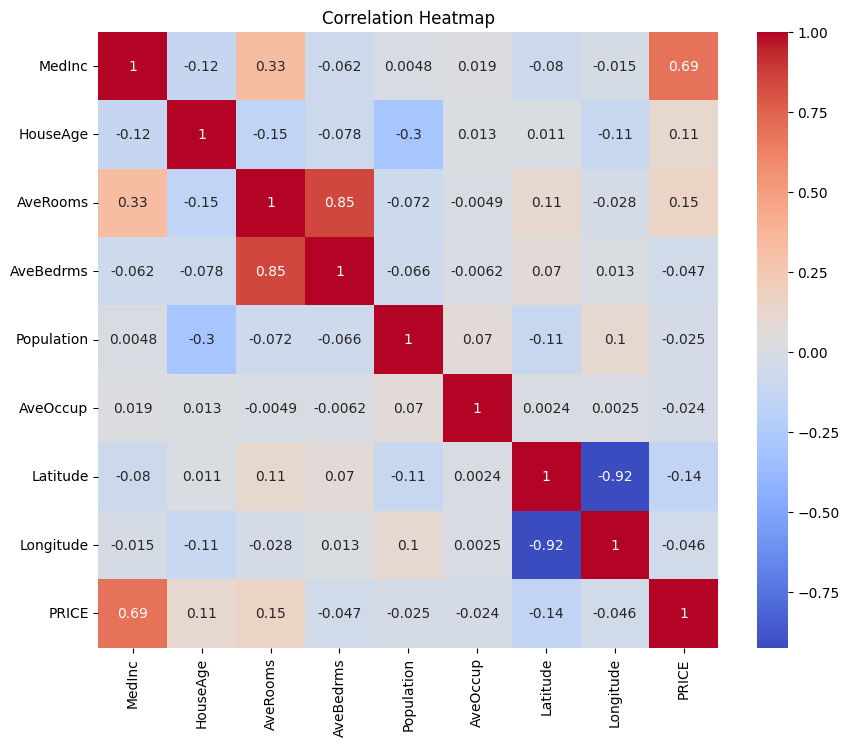

In [7]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

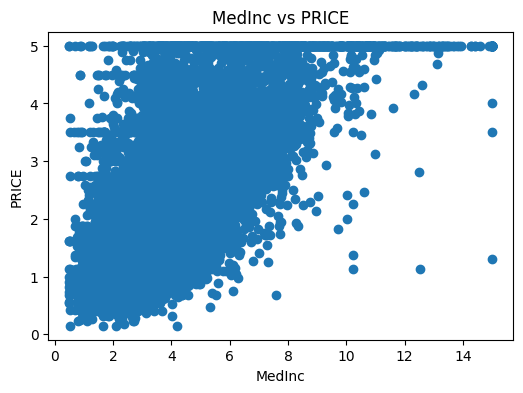

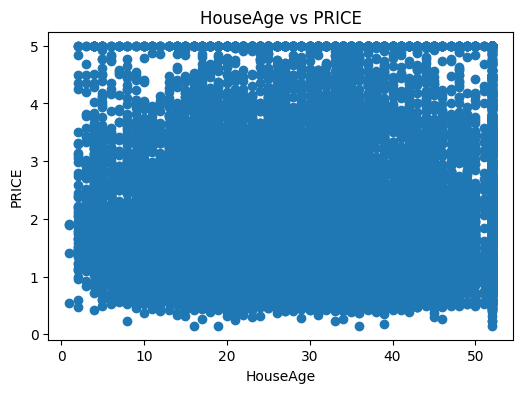

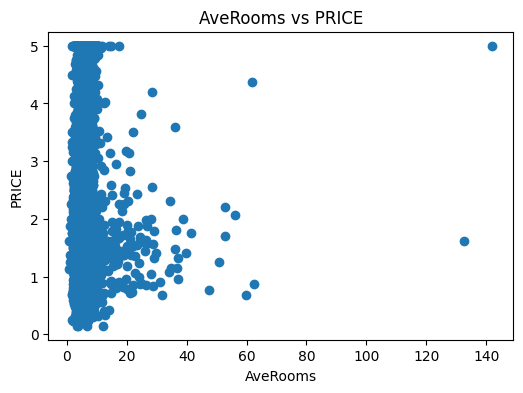

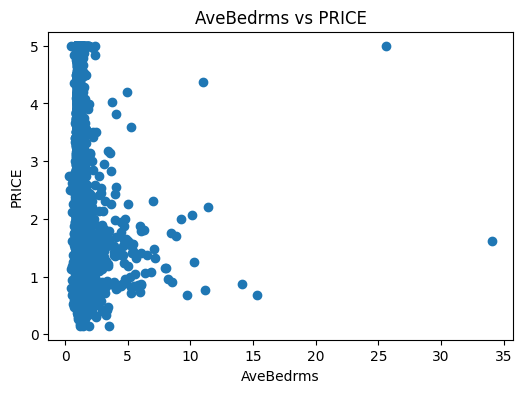

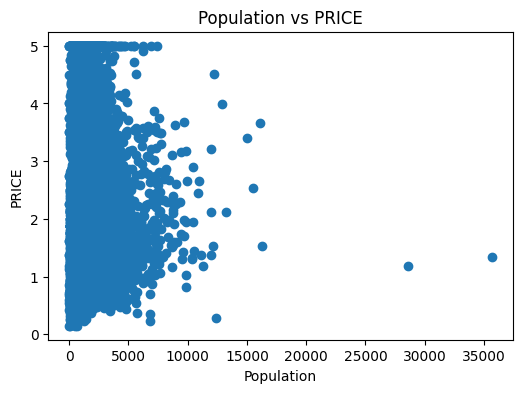

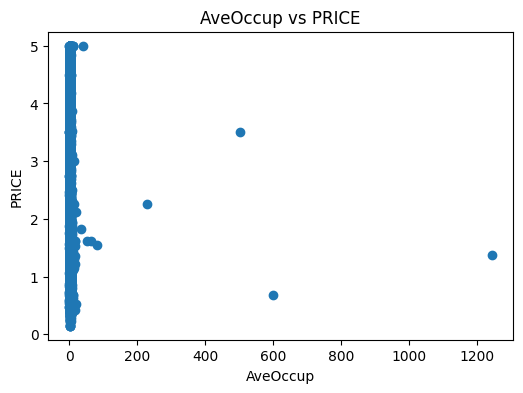

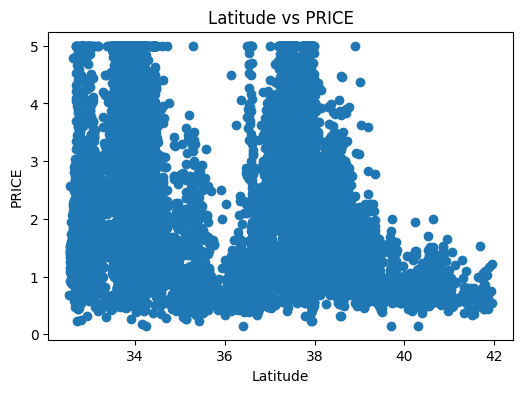

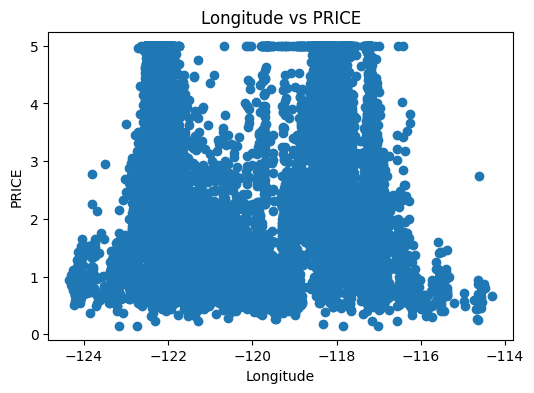

In [8]:
# Function for Scatter Plots
def feature_vs_target(dataframe, target):

    features = dataframe.drop(columns=[target]).columns

    for feature in features:
        plt.figure(figsize=(6,4))
        plt.scatter(dataframe[feature], dataframe[target])
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f"{feature} vs {target}")
        plt.show()

# Visualize all features
feature_vs_target(df, "PRICE")

In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Train Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
# Predictions
y_pred = rf_model.predict(X_test)

In [12]:
# Model Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nInitial Model Performance")
print("RMSE:", rmse)
print("R2 Score:", r2)


Initial Model Performance
RMSE: 0.5053399773665033
R2 Score: 0.8051230593157366


In [18]:
# Hyperparameter Tuning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)



Best Parameters
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [19]:
# Best Model
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("\nTuned Model Performance")
print("RMSE:", rmse_best)
print("R2 Score:", r2_best)


Tuned Model Performance
RMSE: 0.5045713885354675
R2 Score: 0.8057153985083529


In [20]:
# Predict New House Price
new_house = X_test.iloc[[0]]

prediction = best_model.predict(new_house)

print("\nPredicted House Price:")
print(prediction[0])

print("\nActual House Price:")
print(y_test.iloc[0])


Predicted House Price:
0.5023691911163393

Actual House Price:
0.477
